# E-Commerce Revenue Intelligence – Exploratory Data Analysis

This notebook performs exploratory data analysis on the e-commerce dataset to identify patterns in revenue generation, customer behavior, and product performance.

The goal is to extract actionable business insights that can help improve revenue growth, customer retention, and product strategy.

## Business Questions

This analysis aims to answer the following key questions:

1. What does the revenue distribution look like across transactions?
2. Which product categories generate the most revenue?
3. Who are the highest value customers?
4. Are a small number of products responsible for most of the revenue?
5. How do customer reviews relate to product sales?

These insights can support decisions related to pricing strategy, marketing campaigns, and inventory planning.

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [11]:
conn = sqlite3.connect("../database/ecommerce.db")

In [12]:
customers = pd.read_sql("SELECT * FROM customers", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
products = pd.read_sql("SELECT * FROM products", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)

In [13]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)

Customers: (50000, 6)
Orders: (300000, 3)
Products: (2000, 4)
Order Items: (700000, 5)
Reviews: (150000, 5)


The dataset contains multiple relational tables capturing customers, orders, products, and reviews.

This structure enables analysis of purchasing behavior and revenue drivers across the entire platform.

In [14]:
merged = order_items.merge(products, on="product_id")
merged["revenue"] = merged["quantity"] * merged["price"]

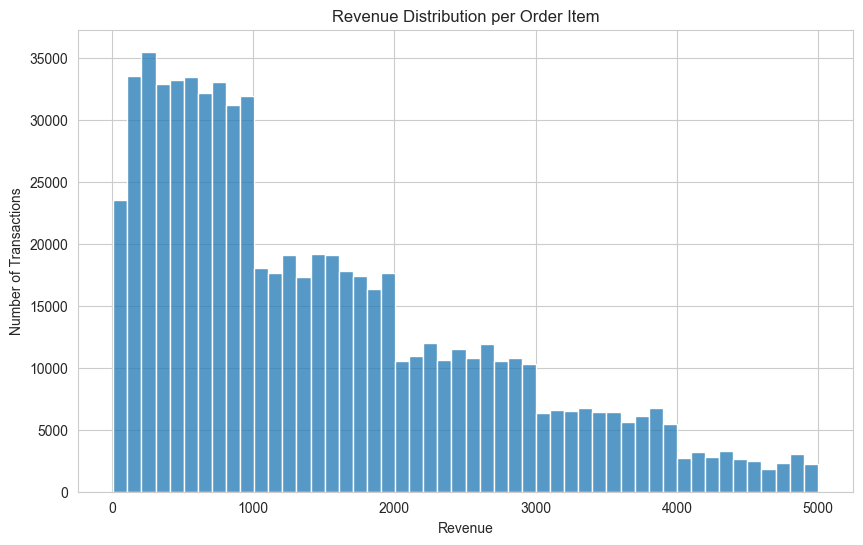

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(merged["revenue"], bins=50)
plt.title("Revenue Distribution per Order Item")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")
plt.show()

### Key Insights

• The revenue distribution is right-skewed, indicating that most transactions generate relatively low revenue.

• A small number of high-value orders create a long tail, contributing disproportionately to overall revenue.

• This suggests that while the platform has a large number of small purchases, high-value transactions play an important role in revenue growth.

• Opportunities exist to increase average order value through product bundling, targeted promotions, and recommendation systems.

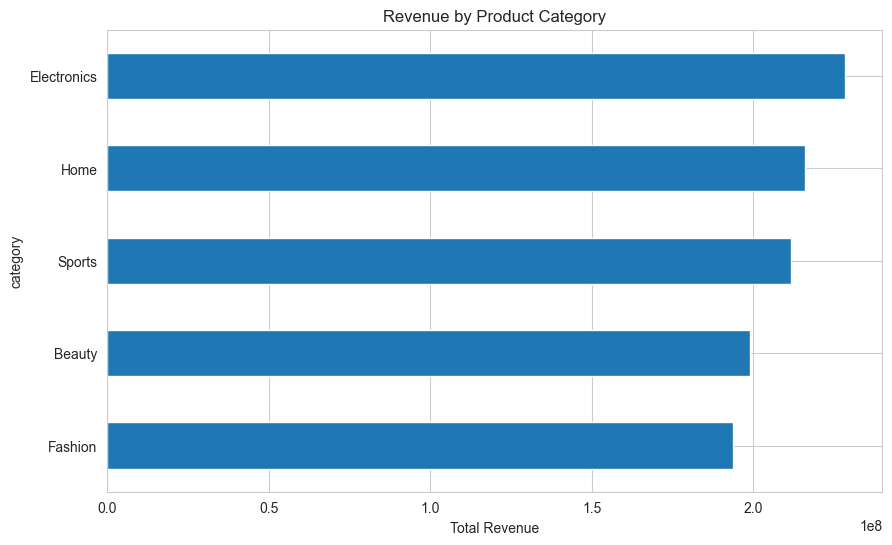

In [16]:
category_sales = merged.groupby("category")["revenue"].sum().sort_values()

plt.figure(figsize=(10,6))
category_sales.plot(kind="barh")
plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.show()

### Category Performance Insights

• Certain product categories dominate overall revenue contribution.

• These categories represent the core business drivers and should receive priority in marketing campaigns and inventory planning.

• Lower performing categories may require promotional strategies or pricing adjustments to improve sales performance.

In [17]:
customer_revenue = merged.merge(orders, on="order_id") \
                         .groupby("customer_id")["revenue"] \
                         .sum() \
                         .sort_values(ascending=False) \
                         .head(10)

customer_revenue

customer_id
CUST_48539    84324.77
CUST_47010    78355.41
CUST_44770    78087.25
CUST_8851     78048.09
CUST_45235    77511.31
CUST_32381    76226.60
CUST_38199    75410.68
CUST_43504    75292.41
CUST_11700    75195.36
CUST_2182     74364.25
Name: revenue, dtype: float64

### Customer Value Insights

• A small subset of customers generates a disproportionately high share of revenue.

• Identifying and retaining these high-value customers is critical for long-term revenue growth.

• Businesses often target these customers with loyalty programs and personalized marketing campaigns.

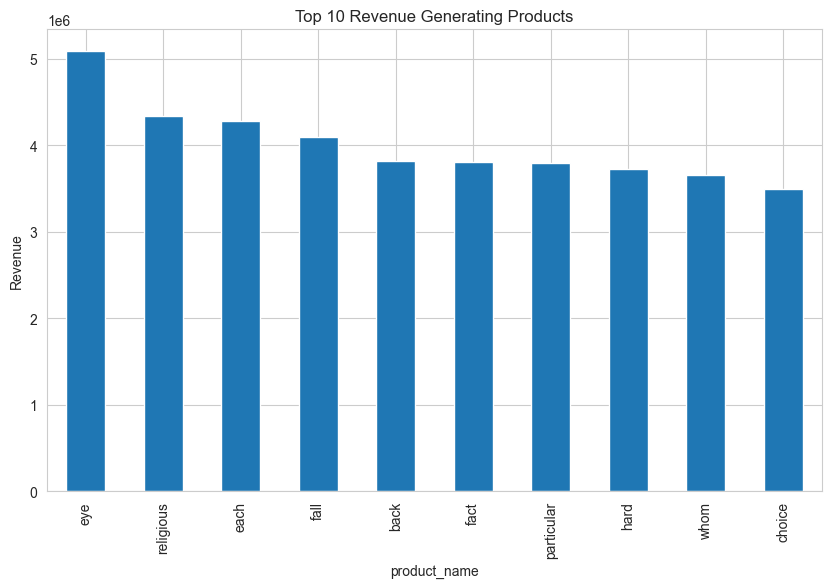

In [19]:
top_products = merged.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")
plt.title("Top 10 Revenue Generating Products")
plt.ylabel("Revenue")
plt.show()

## Conclusion

This exploratory analysis highlights several key drivers of revenue performance:

• Revenue is concentrated in a small number of high-value transactions.  
• Certain product categories contribute disproportionately to sales.  
• A small group of high-value customers drives a significant portion of revenue.  
• Customer reviews indicate generally high satisfaction levels.

These insights can support strategic decisions related to product management, pricing strategies, and customer retention initiatives.